/Users/ed/.pyenv/versions/orbisenv/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ed/.pyenv/versions/orbisenv/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/Users/ed/.pyenv/versions/orbisenv/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/var/folders/tb/dp6t83bd03lb6fh7bn5xwmn80000gn/T/ipykernel_28102/1085741597.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Map with overview inset saved to terra_albers_overview_map.png


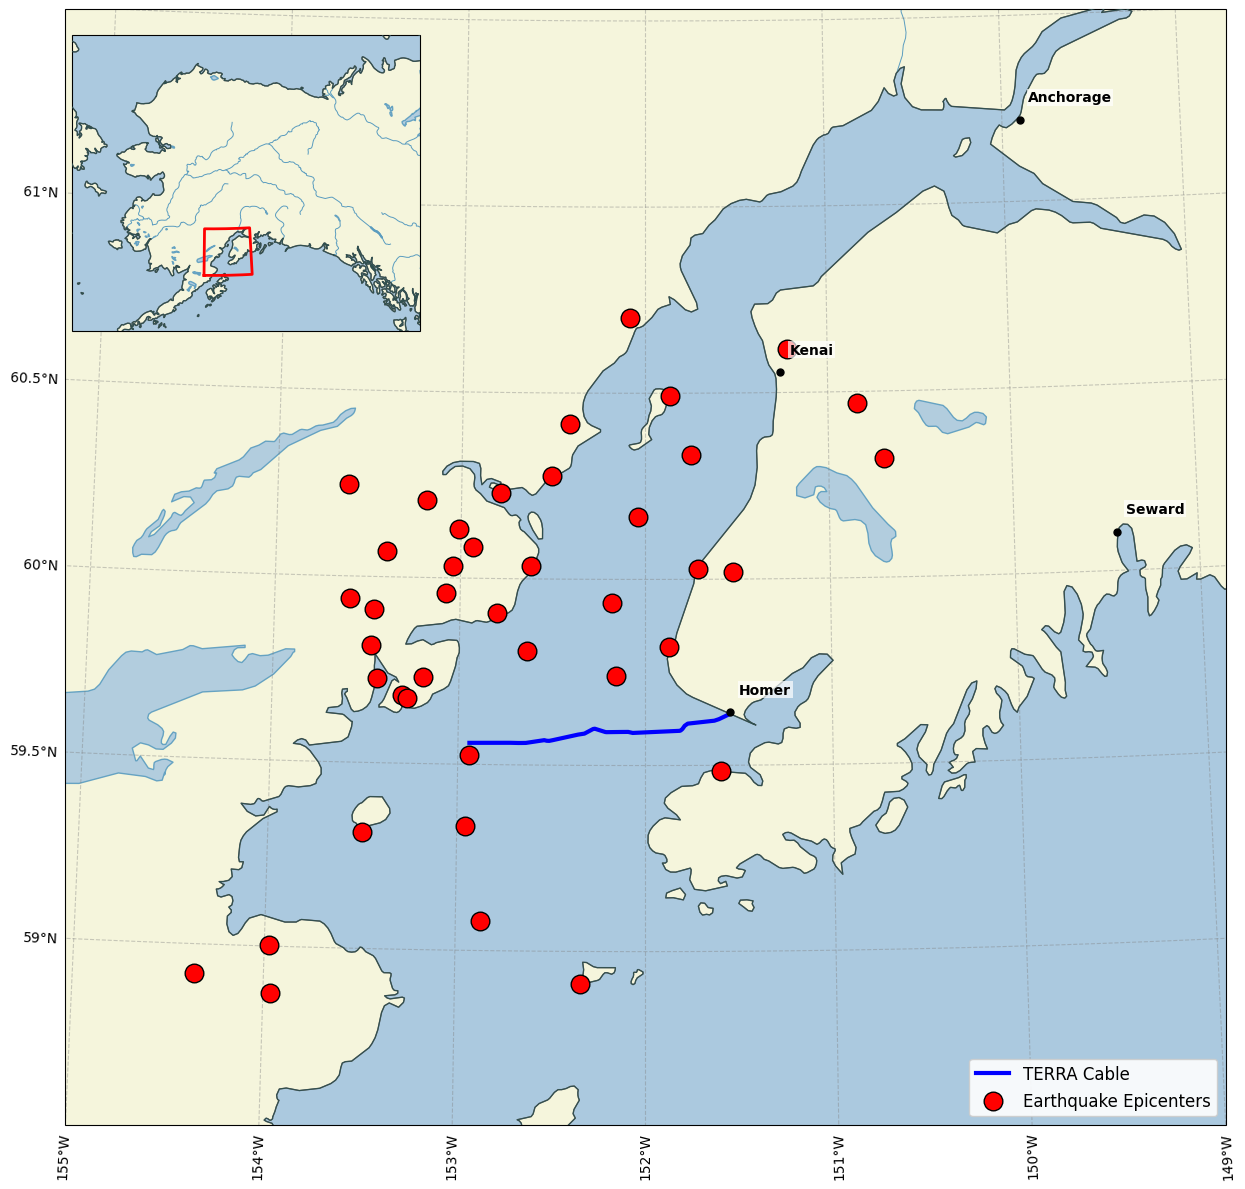

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def albers_terra_plot():
    # Define window based on your updated coordinates
    center_lat, center_lon = 60.0, -152.0
    lon_buffer = 3.0 
    lat_buffer = 1.5
    
    min_lat, max_lat = center_lat - lat_buffer, center_lat + lat_buffer
    min_lon, max_lon = center_lon - lon_buffer, center_lon + lon_buffer

    # Path for JSON in the working directory
    json_path = 'event_metadata_cache.json'
    data_dir = '../das_coords_bathymetry/'
    
    try:
        # Load TERRA cable
        terra_path = os.path.join(data_dir, 'TERRA_coords.xycz')
        terra = pd.read_csv(terra_path, sep=r'\s+', 
                            header=None, names=['lon','lat','cha','dep'])
        
        # Load Events JSON
        with open(json_path, 'r') as f:
            events_data = json.load(f)
            if isinstance(events_data, dict):
                events_list = list(events_data.values())
                events_df = pd.DataFrame(events_list)
            else:
                events_df = pd.DataFrame(events_data)
            
    except Exception as e:
        print(f"Error loading files: {e}")
        return

    # Set up Albers Equal Area projection
    albers_proj = ccrs.AlbersEqualArea(central_longitude=center_lon, 
                                      central_latitude=center_lat,
                                      standard_parallels=(55, 65))

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(1, 1, 1, projection=albers_proj)
    
    # Set the main map extent
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    # Helper function to add map features to an axis
    def add_map_features(target_ax, scale='10m'):
        target_ax.add_feature(cfeature.OCEAN.with_scale(scale), facecolor='#ABC9DF', zorder=0)
        target_ax.add_feature(cfeature.LAND.with_scale(scale), facecolor='#F5F5DC', edgecolor='#666666', zorder=1)
        target_ax.add_feature(cfeature.LAKES.with_scale(scale), facecolor='#ABC9DF', edgecolor='#5A9CBF', alpha=0.9, zorder=2)
        target_ax.add_feature(cfeature.RIVERS.with_scale(scale), edgecolor='#5A9CBF', linewidth=0.7, zorder=2)
        target_ax.add_feature(cfeature.COASTLINE.with_scale(scale), linewidth=0.8, color='#2F4F4F', zorder=4)


    add_map_features(ax, scale='10m')

    # Function to add city labels
    def add_cities(target_ax):
        cities = {
            'Anchorage': (-149.9003, 61.2181),
            'Homer': (-151.5483, 59.6425),
            'Seward': (-149.4422, 60.1042),
            'Kenai': (-151.2583, 60.5544)
        }
        
        for city, (lon, lat) in cities.items():
            extent = target_ax.get_extent(crs=ccrs.PlateCarree())
            if extent[0] <= lon <= extent[1] and extent[2] <= lat <= extent[3]:
                target_ax.plot(lon, lat, 'ko', markersize=5, transform=ccrs.PlateCarree(), zorder=30)
                target_ax.text(lon + 0.05, lat + 0.05, city, transform=ccrs.PlateCarree(),
                              fontsize=10, fontweight='bold', zorder=31,
                              bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    add_cities(ax)

    # Plot TERRA Cable
    ax.plot(terra['lon'], terra['lat'], color='#0000FF', linewidth=3.0, 
            label='TERRA Cable', transform=ccrs.PlateCarree(), zorder=20)

    # Process and Plot Events
    if not events_df.empty:
        lat_key = 'lat' if 'lat' in events_df.columns else 'latitude'
        lon_key = 'lon' if 'lon' in events_df.columns else 'longitude'
        
        events_df[lat_key] = pd.to_numeric(events_df[lat_key], errors='coerce')
        events_df[lon_key] = pd.to_numeric(events_df[lon_key], errors='coerce')
        events_df = events_df.dropna(subset=[lat_key, lon_key])

        events_subset = events_df[
            (events_df[lon_key] >= min_lon) & (events_df[lon_key] <= max_lon) &
            (events_df[lat_key] >= min_lat) & (events_df[lat_key] <= max_lat)
        ]
        
        ax.scatter(events_subset[lon_key], events_subset[lat_key], 
                   s=180, color='#FF0000', edgecolor='black', linewidths=1.0,
                   label='Earthquake Epicenters', transform=ccrs.PlateCarree(), zorder=25)

    # --- ADD OVERVIEW INSET MAP ---
    # Position in upper right, using Alaska-wide extent
    ax_overview = inset_axes(ax, width="30%", height="30%", loc='upper left',
                             axes_class=GeoAxes, 
                             axes_kwargs={'map_projection': ccrs.LambertConformal(central_longitude=-154, central_latitude=63)})
    
    # Alaska mainland extent
    ax_overview.set_extent([-170, -130, 54, 72], crs=ccrs.PlateCarree())
    add_map_features(ax_overview, scale='50m') # Lower res for overview
    
    # Add a rectangle showing the main map's area
    n_pts = 50
    lons = np.r_[np.linspace(min_lon, max_lon, n_pts), [max_lon]*n_pts, np.linspace(max_lon, min_lon, n_pts), [min_lon]*n_pts]
    lats = np.r_[[min_lat]*n_pts, np.linspace(min_lat, max_lat, n_pts), [max_lat]*n_pts, np.linspace(max_lat, min_lat, n_pts)]
    
    ax_overview.plot(lons, lats, color='red', linewidth=2, transform=ccrs.PlateCarree(), zorder=10)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4, zorder=5, 
                      x_inline=False, y_inline=False, color='gray')
    gl.top_labels = False
    gl.right_labels = False

    
    ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=12)

    plt.tight_layout()
    output_file = 'terra_albers_overview_map.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Map with overview inset saved to {output_file}")
    plt.show()

if __name__ == "__main__":
    albers_terra_plot()